# 08 — Regional comparison: does the pattern hold everywhere?

`05` found retail gas prices rise faster than they fall in response to crude oil moves, averaged
over 2010–2026 and over the whole country: 43 cents of a $1/gal crude increase reaches the pump
within the same week, against 26 cents of a $1/gal decrease.

That national figure averages five regions with very different fuel systems. The Gulf Coast is
where most US refining and pipeline capacity sits. The West Coast has no pipeline connection to
the rest of the country and fuel-blend rules that limit which outside supply can be sold there.
Averaging them together hides any of that.

This notebook refits `05`'s model once per region. The retail data is published by PADD (Petroleum Administration for Defense Districts), five multi-state regions the US has used for fuel
accounting since the 1940s. There is no state-level series in this project's data, so nothing
smaller than a PADD can be examined here.

In [1]:
import contextlib
import io
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.asymmetry import (
    DEFAULT_HAC_MAXLAGS,
    build_design_matrix,
    cumulative_passthrough,
    fit_distributed_lag,
    test_asymmetry,
)
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, load_series

DAILY_CRUDE_SERIES_ID = "DCOILWTICO"

K = 4  # crude → retail primary spec, chosen in 04_lag_structure.ipynb §5 and used in 05/06/07

# Regional retail series, in PADD order. The national series is carried as a reference row so
# every regional number can be read against the figure 05 reported.
REGIONS = [
    ("PADD 1", "GASREGECW", "East Coast"),
    ("PADD 2", "GASREGMWW", "Midwest"),
    ("PADD 3", "GASREGGCW", "Gulf Coast"),
    ("PADD 4", "GASREGRMW", "Rocky Mountain"),
    ("PADD 5", "GASREGWCW", "West Coast"),
    ("US", RETAIL_SERIES_ID, "national average"),
]

COLOR_UP = "#eb6834"
COLOR_DOWN = "#2a78d6"
COLOR_CRUDE = "#4a3aa7"
COLOR_REFERENCE = "#8a887c"
COLOR_GRID = "#e1e0d9"


@contextlib.contextmanager
def _quiet():
    """build_design_matrix prints sample attrition, which reads fine when called once (05, 06)
    but repeats six times here. Suppressed locally rather than changing the function -- 05 and
    06 have committed outputs containing those lines."""
    with contextlib.redirect_stdout(io.StringIO()):
        yield


def display_with_pvalue(df, col="p_value", threshold=0.0001):
    """round(4) turns any p-value smaller than 0.0001 into a misleading literal 0.0000.
    Anything that small is shown as '<0.0001' instead of being rounded away."""
    out = df.round(4).copy()
    out[col] = df[col].apply(lambda p: (f"<{threshold}" if pd.notna(p) and p < threshold else (f"{p:.4f}" if pd.notna(p) else "")))
    return out


weekly_crude = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
daily_crude = load_series(PROCESSED_DIR / "crude.csv", DAILY_CRUDE_SERIES_ID, "daily").dropna(subset=["value"]).reset_index(drop=True)

# Same one-row trim as 04/05: daily crude's first usable close is 2010-01-04, so any weekly
# series starting on or before that has no valid daily_pit lookback for its first row. Applied
# here even though this notebook uses only the weekly alignment, so the regional fits share
# 05's sample exactly and their gaps are directly comparable to its 0.4333.
cutoff = daily_crude["date"].min()

retail_by_region = {}
for region, series_id, _ in REGIONS:
    full = load_series(PROCESSED_DIR / "retail.csv", series_id, "weekly-mon")
    retail_by_region[region] = full[full["date"] > cutoff].reset_index(drop=True)

print(f"{len(REGIONS)} series loaded, {len(retail_by_region['US'])} rows each after the trim")

6 series loaded, 865 rows each after the trim


## 1. What is being tested, fixed before any model is fitted

Three questions are asked of this data:

**H1 — does each region show the pattern on its own?** 

**H4 — do some regions react later than others?** 
<br>`05` found the national response to a price drop peaks a week late and
then lingers for a month, while the response to a rise arrives at once and fades. Regions further
from where fuel is refined and shipped should stretch that whole path out, in both directions.

**H2 — is one region's gap genuinely different from another's?** 
<br>PADD 5 against PADD 3, at horizon 0, with $0.10 per $1/gal of crude movement as the smallest
difference worth calling meaningful.
The pair comes from how the fuel system is built, not from these results. PADD 3 is the refining
and pipeline core — the best-supplied, most competitive market available in this data. PADD 5 is
the most isolated. If competitive pressure is what makes retailers pass price *drops* through
quickly, that is where the difference should be largest.

Horizon 0 is primary because `05` §2b and §6 found the same-week gap survived every robustness
check while the week-1 gap did not: it lost significance once the 14 extreme weeks were dropped
(0.145, p = 0.17) and was marginal under a shorter HAC window. Horizon 1 is reported second, with
that instability attached.

$0.10 is a little under a quarter of the $0.4333 national same-week gap.
Recording this here, ahead of the fits, is the point. H1 and H4 both involve looking at all five
regions; choosing H2's pair afterwards would mean picking the comparison that already looked
biggest, which would return a significant result and mean nothing.

## 2. One fit per region

`05`'s primary specification, unchanged: crude → retail, K = 4, weekly alignment, HAC standard
errors at `maxlags=6`. The only thing that varies across the six fits is which retail series goes
in as the dependent variable.

Every regional series carries the same Monday survey dates as the national one, so ADR-0002's
point-in-time guard — which refuses to pair a retail Monday with any crude observation dated after
it — applies unchanged and runs inside each `build_design_matrix` call.

In [2]:
fits = {}
with _quiet():
    for region, _, _ in REGIONS:
        design = build_design_matrix(retail_by_region[region], weekly_crude, K=K, mode="weekly")
        fits[region] = {
            "design": design,
            "res": fit_distributed_lag(design, maxlags=DEFAULT_HAC_MAXLAGS),
        }

region_rows = []
for region, _, label in REGIONS:
    res = fits[region]["res"]
    h0 = test_asymmetry(res, K=K, horizon=0)
    h1 = test_asymmetry(res, K=K, horizon=1)
    region_rows.append(
        {
            "region": region,
            "area": label,
            "up_lag0": res.params["d_up_lag0"],
            "down_lag0": res.params["d_down_lag0"],
            "gap_h0": h0["estimate"],
            "ci_lo": h0["ci_lo"],
            "ci_hi": h0["ci_hi"],
            "p_value": h0["p_value"],
            "gap_h1": h1["estimate"],
            "p_h1": h1["p_value"],
            "n_rows": len(fits[region]["design"]),
        }
    )

region_table = pd.DataFrame(region_rows)
display_with_pvalue(display_with_pvalue(region_table), col="p_h1")

,region,area,up_lag0,down_lag0,gap_h0,ci_lo,ci_hi,p_value,gap_h1,p_h1,n_rows
0,PADD 1,East Coast,0.6638,0.2293,0.4345,0.2022,0.6668,0.0002,0.2277,0.0320,860
1,PADD 2,Midwest,0.7836,0.3737,0.4099,0.1962,0.6237,0.0002,0.1397,0.2259,860
2,PADD 3,Gulf Coast,0.7337,0.2909,0.4428,0.1955,0.6902,0.0005,0.1883,0.1629,860
3,PADD 4,Rocky Mountain,0.5116,0.1938,0.3178,-0.0040,0.6395,0.0529,0.3045,0.1244,860
4,PADD 5,West Coast,0.6111,0.1325,0.4786,0.1895,0.7678,0.0012,0.4561,0.0073,860
5,US,national average,0.6963,0.2629,0.4333,0.2212,0.6454,<0.0001,0.2331,0.0239,860


**Four of the five regions show the pattern.** PADD 1, 2, 3 and 5 clear the stricter 0.01 that
five simultaneous tests call for, not just 0.05. The national row is `05`'s published result,
carried as a reference rather than a sixth test.

**PADD 4 is not measured precisely enough to say.** Its interval clips zero at the bottom but
reaches 0.64 at the top, so an asymmetry as large as any other region's would fit inside it. That
is not evidence of symmetry. Bennett, Owyang & Vermann (2021) found many US cities with no
detectable asymmetry.

**The gap hides what produces it.** PADD 5's is the widest, but its same-week up-response (0.6111)
is *below* the national 0.6963; what sets it apart is the slowest down-response in the sample
(0.1325). The West Coast gap is a slow fall, not a fast rise. PADD 4 is slow in both directions at
once — a market where everything arrives late rather than one treating rises and falls
differently.

**The ranking does not follow supply isolation.** The Gulf Coast, the refining and pipeline core,
has the second-widest gap. Two separately fitted intervals carry no standard error for the
difference between them, so nothing here settles whether PADD 5 and PADD 3 differ.

**PADD 5's gap survives a week; most others don't.** It holds at 0.4561 (p = 0.0073) while the
Midwest and Gulf Coast fall away to insignificance.

## 3. The gap, region by region

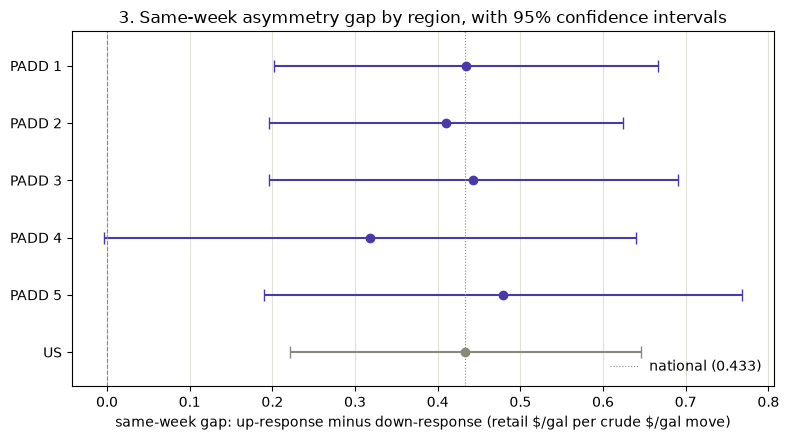

In [3]:
plot_table = region_table.set_index("region")
national_gap = plot_table.loc["US", "gap_h0"]
order = [region for region, _, _ in REGIONS][::-1]  # PADD 1 at the top, US at the bottom

fig, ax = plt.subplots(figsize=(8, 4.5))

for y, region in enumerate(order):
    row = plot_table.loc[region]
    is_reference = region == "US"
    ax.errorbar(
        row["gap_h0"],
        y,
        xerr=[[row["gap_h0"] - row["ci_lo"]], [row["ci_hi"] - row["gap_h0"]]],
        fmt="o",
        color=COLOR_REFERENCE if is_reference else COLOR_CRUDE,
        capsize=4,
    )

ax.axvline(0, color="#8a887c", linewidth=0.8, linestyle="--")
ax.axvline(national_gap, color=COLOR_REFERENCE, linewidth=0.8, linestyle=":", label=f"national ({national_gap:.3f})")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_ylim(-0.6, len(order) - 0.4)
ax.set_xlabel(r"same-week gap: up-response minus down-response (retail \$/gal per crude \$/gal move)")
ax.set_title("3. Same-week asymmetry gap by region, with 95% confidence intervals")
ax.grid(True, axis="x", color=COLOR_GRID)
ax.legend(frameon=False, loc="lower right")

plt.tight_layout()
plt.show()

**Every regional interval contains the national estimate**, and all five overlap each other almost
entirely. The spread from the widest regional gap to the narrowest is 0.161, against 0.428 for
even the tightest regional interval, so the ordering in the table is small relative to the
uncertainty behind any single row, and noise alone could rearrange it.

**Regional estimates are less precise than the national one.** PADD 2 matches the national
interval width; the rest are wider, PADD 4's by half again. Averaging the regions together cancels
region-specific noise, which is why the national figure is the most precisely measured number in
the chart despite describing no actual market. The sample is the same 860 weeks everywhere, so
this is about how closely each region tracks crude, not about how much data it has.

## 4. The shape behind each number

The gap in §3 is a single number per region, and two very different situations produce the same
one: a region where increases arrive unusually fast, and a region where decreases arrive unusually
slowly. Plotting the cumulative pass-through of each direction.

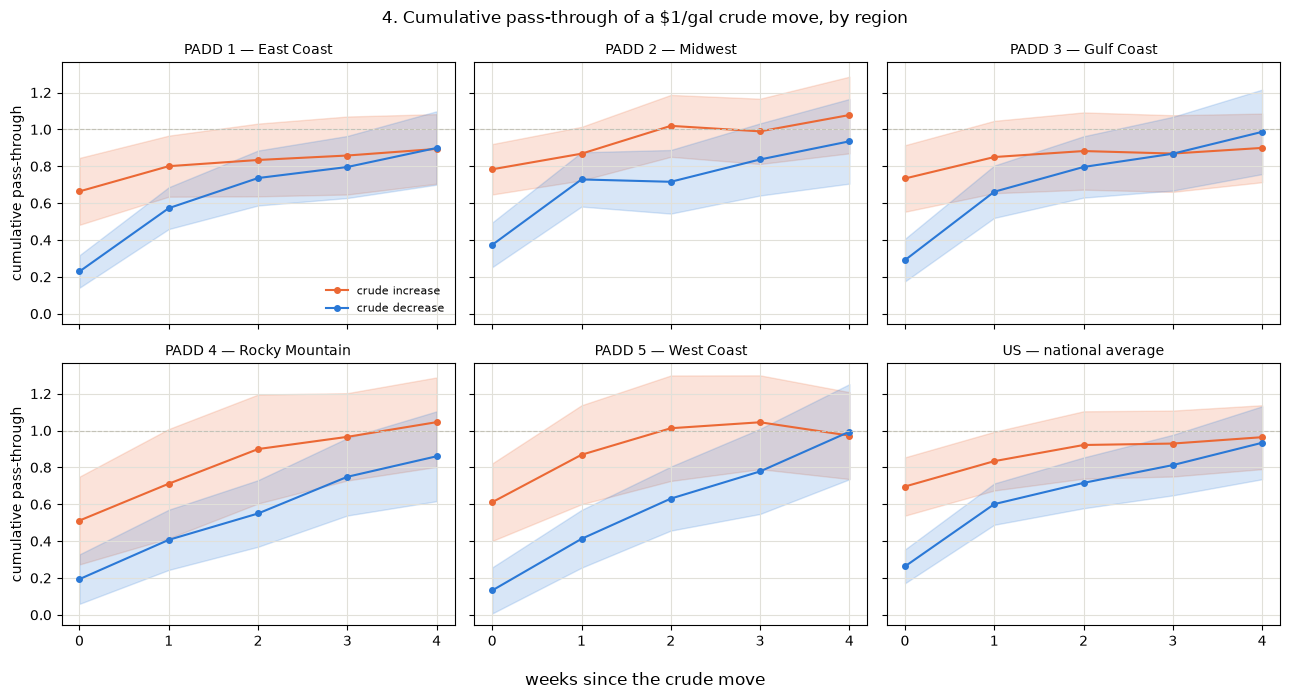

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)

for ax, (region, _, label) in zip(axes.ravel(), REGIONS):
    cp = cumulative_passthrough(fits[region]["res"], K=K)

    ax.plot(cp["horizon"], cp["cum_up"], color=COLOR_UP, marker="o", markersize=4, label="crude increase")
    ax.fill_between(cp["horizon"], cp["cum_up_lo"], cp["cum_up_hi"], color=COLOR_UP, alpha=0.18)

    ax.plot(cp["horizon"], cp["cum_down"], color=COLOR_DOWN, marker="o", markersize=4, label="crude decrease")
    ax.fill_between(cp["horizon"], cp["cum_down_lo"], cp["cum_down_hi"], color=COLOR_DOWN, alpha=0.18)

    ax.axhline(1.0, color="#c3c2b7", linewidth=0.8, linestyle="--")
    ax.set_title(f"{region} — {label}", fontsize=10)
    ax.set_xticks(cp["horizon"])
    ax.grid(True, color=COLOR_GRID)

for ax in axes[:, 0]:
    ax.set_ylabel("cumulative pass-through")

axes[0, 0].legend(frameon=False, loc="lower right", fontsize=8)
fig.suptitle("4. Cumulative pass-through of a $1/gal crude move, by region")
fig.supxlabel("weeks since the crude move")

plt.tight_layout()
plt.show()

## 5. What H1 shows

Four of the five regions show a statistically significant gap, each with p ≤ 0.0012 — far below
the usual 0.05, and still below the stricter 0.01 that testing five regions at once calls for.
PADD 4 does not (p = 0.053): its gap is the smallest (0.318) and its interval touches zero. That
means no detectable gap in the Rocky Mountains, not no gap — an effect nearly as large as the
national one still sits inside its interval.

PADD 5 and PADD 3 (the pair fixed for H2) sit at the top, but their intervals overlap heavily ([0.190, 0.768] and [0.196, 0.690]). §3 ranks them and it does not show they differ, which is exactly why H2 exists as a separate test.

§4 shows those same two regions taking different paths to a similar §3 number. PADD 5's gap stays
close to its week-0 size through week 3 (0.479 at week 0, still 0.267 at week 3) before closing
abruptly in the final week (0.973 versus 0.994 cumulative pass-through by week 4). PADD 3's gap
shrinks steadily from the start (already down to 0.188 by week 1) and crosses to slightly
negative by week 4 (0.900 versus 0.987). Both end up close to full, symmetric pass-through by
week 4.